**Project Name :**

COVID-19 Global Trends Analysis and Insights Dashboard

**Tools Used:**

• Python

• Pandas

• NumPy

• Matplotlib

• Seaborn

• Google Colab

**Datasets Used:**
1. worldometer_coronavirus_daily_data.csv
2. worldometer_coronavirus_summary_data.csv

This project analyzes COVID-19 trends using two Worldometer datasets. The daily dataset will be used for time-series analysis, while the summary dataset will be used for country comparisons and rankings.

These libraries are used for data loading, cleaning, analysis, and visualization. Pandas manages data, NumPy handles calculations, and Matplotlib/Seaborn create charts.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Google Colab allows multiple files to be uploaded simultaneously. Select both CSV files together from your computer.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving worldometer_coronavirus_daily_data.csv to worldometer_coronavirus_daily_data.csv
Saving worldometer_coronavirus_summary_data.csv to worldometer_coronavirus_summary_data.csv


This step confirms both datasets are available inside the notebook environment.

In [3]:
import os

print(os.listdir())

['.config', 'worldometer_coronavirus_summary_data.csv', 'worldometer_coronavirus_daily_data.csv', 'sample_data']


The datasets are loaded into separate DataFrames because they serve different purposes in the project.

In [4]:
daily_df = pd.read_csv(
    'worldometer_coronavirus_daily_data.csv'
)

summary_df = pd.read_csv(
    'worldometer_coronavirus_summary_data.csv'
)

Displaying the first five records helps understand the structure and contents of both datasets.

In [5]:
daily_df.head()

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN


In [6]:
summary_df.head()

,country,continent,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
0,Afghanistan,Asia,179267,7690.0,162202.0,9375.0,1124.0,4420,190.0,951337.0,23455.0,40560636
1,Albania,Europe,275574,3497.0,271826.0,251.0,2.0,95954,1218.0,1817530.0,632857.0,2871945
2,Algeria,Africa,265816,6875.0,178371.0,80570.0,6.0,5865,152.0,230861.0,5093.0,45325517
3,Andorra,Europe,42156,153.0,41021.0,982.0,14.0,543983,1974.0,249838.0,3223924.0,77495
4,Angola,Africa,99194,1900.0,97149.0,145.0,NaN,2853,55.0,1499795.0,43136.0,34769277


The shape function shows the number of rows and columns present in each dataset.

In [7]:
print("Daily Dataset Shape:", daily_df.shape)

print("Summary Dataset Shape:", summary_df.shape)

Daily Dataset Shape: (184787, 7)
Summary Dataset Shape: (226, 12)


Before analysis, we must understand the available columns and their exact names.

In [8]:
print(daily_df.columns)

print(summary_df.columns)

Index(['date', 'country', 'cumulative_total_cases', 'daily_new_cases',
       'active_cases', 'cumulative_total_deaths', 'daily_new_deaths'],
      dtype='object')
Index(['country', 'continent', 'total_confirmed', 'total_deaths',
       'total_recovered', 'active_cases', 'serious_or_critical',
       'total_cases_per_1m_population', 'total_deaths_per_1m_population',
       'total_tests', 'total_tests_per_1m_population', 'population'],
      dtype='object')


The info() function displays data types, missing values, and overall structure.

In [9]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184787 entries, 0 to 184786
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     184787 non-null  object 
 1   country                  184787 non-null  object 
 2   cumulative_total_cases   184787 non-null  float64
 3   daily_new_cases          174329 non-null  float64
 4   active_cases             166747 non-null  float64
 5   cumulative_total_deaths  178227 non-null  float64
 6   daily_new_deaths         157850 non-null  float64
dtypes: float64(5), object(2)
memory usage: 9.9+ MB


In [10]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         226 non-null    object 
 1   continent                       226 non-null    object 
 2   total_confirmed                 226 non-null    int64  
 3   total_deaths                    218 non-null    float64
 4   total_recovered                 204 non-null    float64
 5   active_cases                    204 non-null    float64
 6   serious_or_critical             145 non-null    float64
 7   total_cases_per_1m_population   226 non-null    int64  
 8   total_deaths_per_1m_population  218 non-null    float64
 9   total_tests                     212 non-null    float64
 10  total_tests_per_1m_population   212 non-null    float64
 11  population                      226 non-null    int64  
dtypes: float64(7), int64(3), object(2)
m

Descriptive statistics help understand distributions, averages, and ranges.

In [11]:
daily_df.describe()

,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
count,1.847870e+05,174329.000000,1.667470e+05,1.782270e+05,157850.000000
mean,7.251089e+05,2987.633285,6.239283e+04,1.388600e+04,39.831834
std,3.681471e+06,17803.232663,3.955641e+05,6.049521e+04,181.102770
min,0.000000e+00,-322.000000,-1.432100e+04,0.000000e+00,-39.000000
25%,1.099000e+03,0.000000,6.000000e+01,2.400000e+01,0.000000
50%,1.775600e+04,58.000000,1.386000e+03,3.040000e+02,1.000000
75%,2.238085e+05,728.000000,1.462050e+04,4.111000e+03,12.000000
max,8.420947e+07,909610.000000,1.793543e+07,1.026646e+06,5093.000000


In [12]:
summary_df.describe()

,total_confirmed,total_deaths,total_recovered,active_cases,serious_or_critical,total_cases_per_1m_population,total_deaths_per_1m_population,total_tests,total_tests_per_1m_population,population
count,2.260000e+02,2.180000e+02,2.040000e+02,2.040000e+02,145.000000,226.000000,218.000000,2.120000e+02,2.120000e+02,2.260000e+02
mean,2.305651e+06,2.884442e+04,2.256851e+06,6.861029e+04,269.482759,148156.809735,1157.550459,2.987445e+07,1.944650e+06,3.495521e+07
std,7.575510e+06,9.971254e+04,7.613357e+06,2.350430e+05,883.174727,155202.909225,1212.833590,1.079635e+08,3.318400e+06,1.390338e+08
min,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000,16.000000,2.000000,5.117000e+03,5.093000e+03,8.050000e+02
25%,2.412600e+04,2.370000e+02,1.619300e+04,2.397500e+02,5.000000,11748.250000,172.500000,3.472968e+05,1.667260e+05,5.605125e+05
50%,1.793750e+05,2.251500e+03,1.372740e+05,1.634000e+03,17.000000,98271.500000,768.000000,2.238918e+06,7.753355e+05,5.800570e+06
75%,1.090902e+06,1.400650e+04,1.006245e+06,1.929675e+04,139.000000,255632.750000,1850.000000,1.233862e+07,2.267408e+06,2.187284e+07
max,8.420947e+07,1.026646e+06,8.124426e+07,1.938567e+06,8318.000000,704302.000000,6297.000000,1.016883e+09,2.184247e+07,1.439324e+09


Missing values can affect results and should be identified before proceeding.

In [13]:
daily_df.isnull().sum()

,0
date,0
country,0
cumulative_total_cases,0
daily_new_cases,10458
active_cases,18040
cumulative_total_deaths,6560
daily_new_deaths,26937


In [14]:
summary_df.isnull().sum()

,0
country,0
continent,0
total_confirmed,0
total_deaths,8
total_recovered,22
active_cases,22
serious_or_critical,81
total_cases_per_1m_population,0
total_deaths_per_1m_population,8
total_tests,14


Any missing values are handled and date columns are converted into datetime format for time-series analysis.

In [15]:
daily_df.fillna(0, inplace=True)

summary_df.fillna(0, inplace=True)

In [16]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184787 entries, 0 to 184786
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     184787 non-null  object 
 1   country                  184787 non-null  object 
 2   cumulative_total_cases   184787 non-null  float64
 3   daily_new_cases          184787 non-null  float64
 4   active_cases             184787 non-null  float64
 5   cumulative_total_deaths  184787 non-null  float64
 6   daily_new_deaths         184787 non-null  float64
dtypes: float64(5), object(2)
memory usage: 9.9+ MB


In [17]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         226 non-null    object 
 1   continent                       226 non-null    object 
 2   total_confirmed                 226 non-null    int64  
 3   total_deaths                    226 non-null    float64
 4   total_recovered                 226 non-null    float64
 5   active_cases                    226 non-null    float64
 6   serious_or_critical             226 non-null    float64
 7   total_cases_per_1m_population   226 non-null    int64  
 8   total_deaths_per_1m_population  226 non-null    float64
 9   total_tests                     226 non-null    float64
 10  total_tests_per_1m_population   226 non-null    float64
 11  population                      226 non-null    int64  
dtypes: float64(7), int64(3), object(2)
m

New analytical features help derive deeper insights from the data.

In [20]:
summary_df['death_rate'] = (
    summary_df['total_deaths'] /
    summary_df['total_confirmed']
) * 100

Recovery Rate shows the percentage of confirmed cases that recovered successfully. This helps evaluate how effectively countries managed COVID-19 cases.

In [22]:
summary_df['recovery_rate'] = (
    summary_df['total_recovered']
    /
    summary_df['total_confirmed']
) * 100

Some countries may have missing recovery or death information. This step replaces invalid values and prepares the dataset for analysis.

In [23]:
summary_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

summary_df.fillna(0, inplace=True)

We check whether the newly created columns were added correctly.

In [24]:
summary_df[
    [
        'country',
        'death_rate',
        'recovery_rate'
    ]
].head()

,country,death_rate,recovery_rate
0,Afghanistan,4.289691,90.480680
1,Albania,1.268988,98.639930
2,Algeria,2.586376,67.103184
3,Andorra,0.362938,97.307619
4,Angola,1.915438,97.938383


EDA QUESTION 1

**Which Countries Have The Highest Confirmed Cases?**

This analysis identifies the countries most affected by COVID-19 based on total confirmed infections.

In [25]:
top_cases = summary_df.sort_values(
    by='total_confirmed',
    ascending=False
).head(10)

top_cases[
    [
        'country',
        'total_confirmed'
    ]
]

,country,total_confirmed
216,USA,84209473
94,India,43121599
26,Brazil,30682094
72,France,29160802
78,Germany,25780226
212,UK,22159805
165,Russia,18260293
189,South Korea,17782061
101,Italy,17057873
209,Turkey,15053168


VISUALIZATION 1

**Top 10 Countries By Cases**

This bar chart compares the countries with the highest confirmed COVID-19 cases.

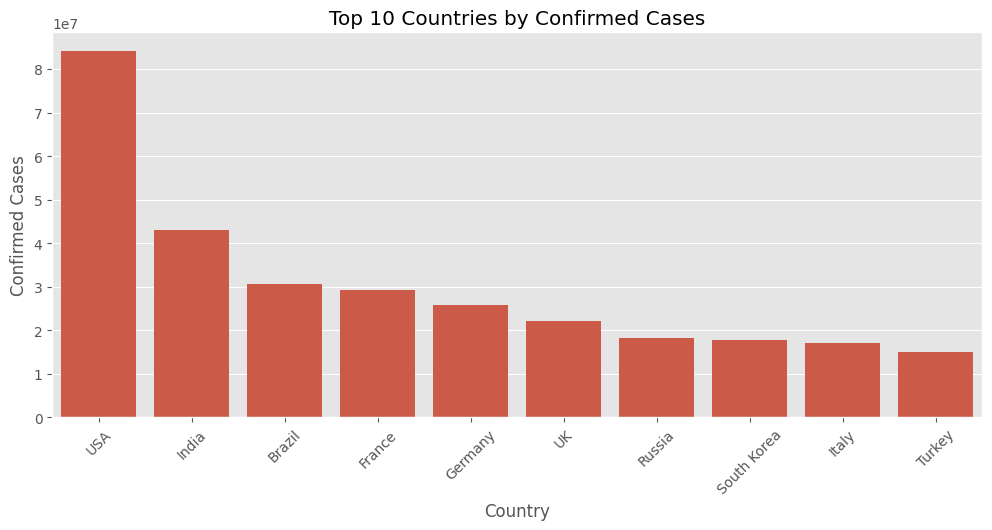

In [26]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='country',
    y='total_confirmed',
    data=top_cases
)

plt.xticks(rotation=45)

plt.title('Top 10 Countries by Confirmed Cases')

plt.xlabel('Country')

plt.ylabel('Confirmed Cases')

plt.show()

EDA QUESTION 2

**Which Countries Have The Highest Death Counts?**

This analysis identifies countries that reported the highest cumulative COVID-19 deaths.

In [27]:
top_deaths = summary_df.sort_values(
    by='total_deaths',
    ascending=False
).head(10)

top_deaths[
    [
        'country',
        'total_deaths'
    ]
]

,country,total_deaths
216,USA,1026646.0
26,Brazil,664920.0
94,India,524214.0
165,Russia,377670.0
131,Mexico,324465.0
158,Peru,213023.0
212,UK,176708.0
101,Italy,165244.0
95,Indonesia,156458.0
72,France,147257.0


VISUALIZATION 2

**Top 10 Countries By Deaths**

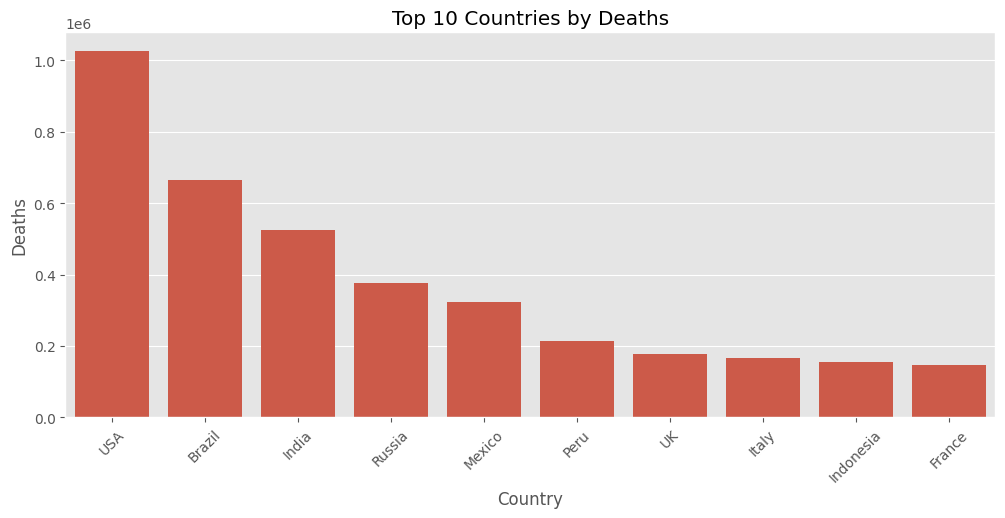

In [28]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='country',
    y='total_deaths',
    data=top_deaths
)

plt.xticks(rotation=45)
plt.title('Top 10 Countries by Deaths')
plt.xlabel('Country')
plt.ylabel('Deaths')
plt.show()

EDA QUESTION 3

**Which Countries Have Highest Recovery Rates?**

This analysis identifies countries with the best recovery performance relative to total confirmed cases.

In [29]:
top_recovery = summary_df.sort_values(
    by='recovery_rate',
    ascending=False
).head(10)

top_recovery[
    [
        'country',
        'recovery_rate'
    ]
]

,country,recovery_rate
90,Holy See,100.000000
43,China Macao Sar,100.000000
168,Saint Helena,100.000000
150,Niue,100.000000
22,Bhutan,99.867383
162,Qatar,99.534381
108,Kuwait,99.531700
57,Denmark,99.453046
100,Israel,99.375596
204,Timor Leste,99.375246


VISUALIZATION 3

**Recovery Rate Comparison**

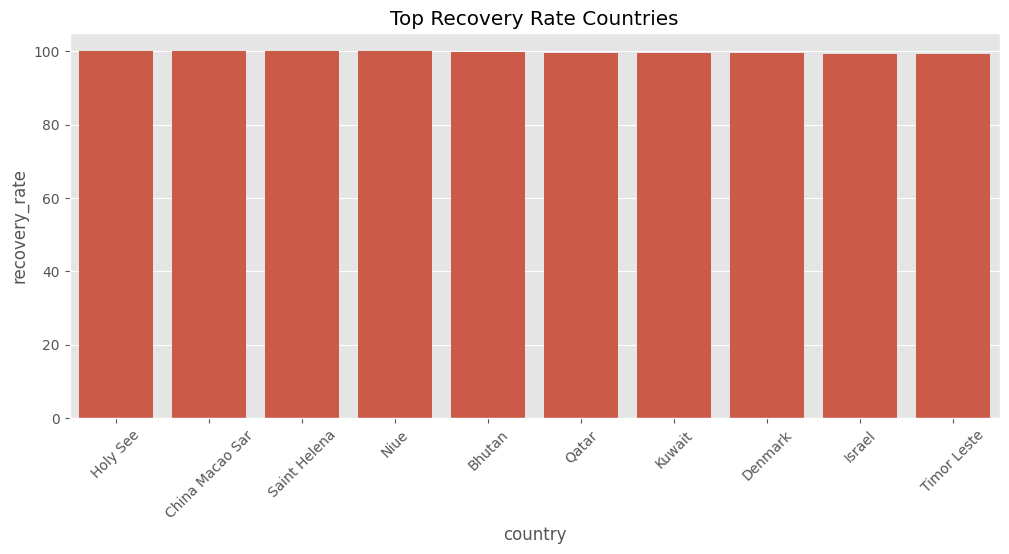

In [30]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='country',
    y='recovery_rate',
    data=top_recovery
)

plt.xticks(rotation=45)

plt.title('Top Recovery Rate Countries')

plt.show()

EDA QUESTION 4

**How Did Global Cases Grow Over Time?**

The daily dataset is grouped by date to examine how confirmed cases changed throughout the pandemic

In [31]:
daily_df['date'] = pd.to_datetime(
    daily_df['date']
)

global_cases = (
    daily_df
    .groupby('date')
    ['cumulative_total_cases']
    .sum()
)

global_cases.head()

,cumulative_total_cases
date,
2020-01-22,571.0
2020-01-23,830.0
2020-01-24,1287.0
2020-01-25,1975.0
2020-01-26,2744.0


VISUALIZATION 4

**Global Cases Trend**

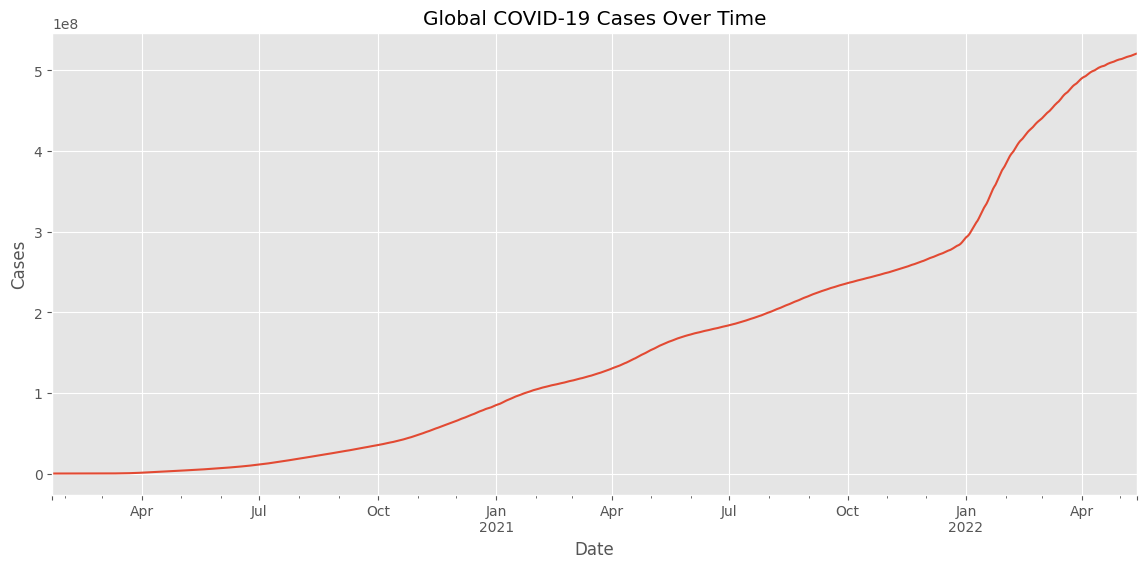

In [32]:
plt.figure(figsize=(14,6))

global_cases.plot()

plt.title(
    'Global COVID-19 Cases Over Time'
)

plt.xlabel('Date')

plt.ylabel('Cases')

plt.show()

EDA QUESTION 5

**How Did Global Deaths Change Over Time?**

This analysis studies the trend of cumulative deaths throughout the pandemic.

In [33]:
global_deaths = (
    daily_df
    .groupby('date')
    ['cumulative_total_deaths']
    .sum()
)

global_deaths.head()

,cumulative_total_deaths
date,
2020-01-22,17.0
2020-01-23,25.0
2020-01-24,41.0
2020-01-25,56.0
2020-01-26,80.0


VISUALIZATION 5

**Global Death Trend**

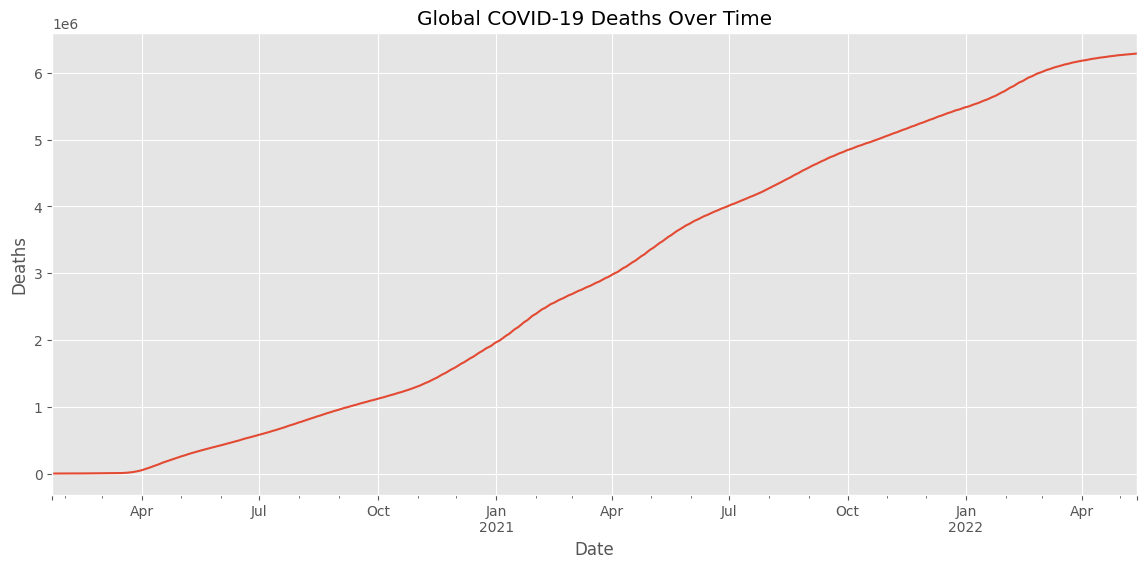

In [34]:
plt.figure(figsize=(14,6))

global_deaths.plot()

plt.title(
    'Global COVID-19 Deaths Over Time'
)

plt.xlabel('Date')

plt.ylabel('Deaths')

plt.show()

VISUALIZATION 6

Histogram

**The histogram shows the distribution of confirmed cases across countries.**

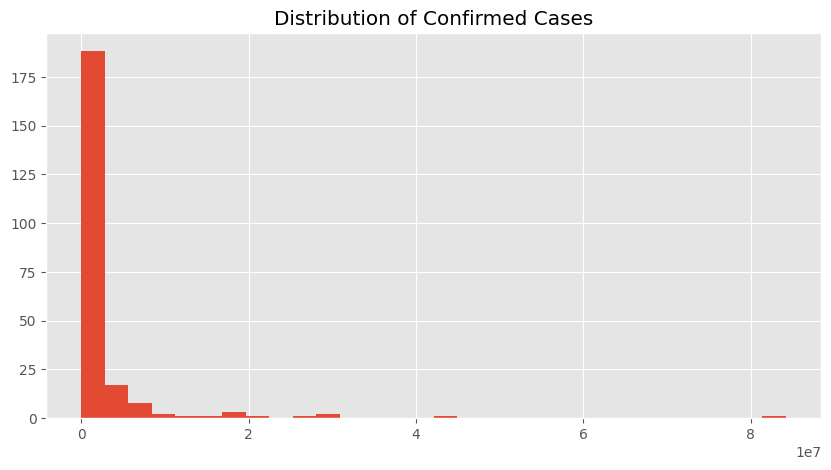

In [35]:
plt.figure(figsize=(10,5))

plt.hist(
    summary_df['total_confirmed'],
    bins=30
)

plt.title(
    'Distribution of Confirmed Cases'
)

plt.show()

VISUALIZATION 8

Correlation Heatmap

**The heatmap displays correlations among numerical COVID-19 variables.**

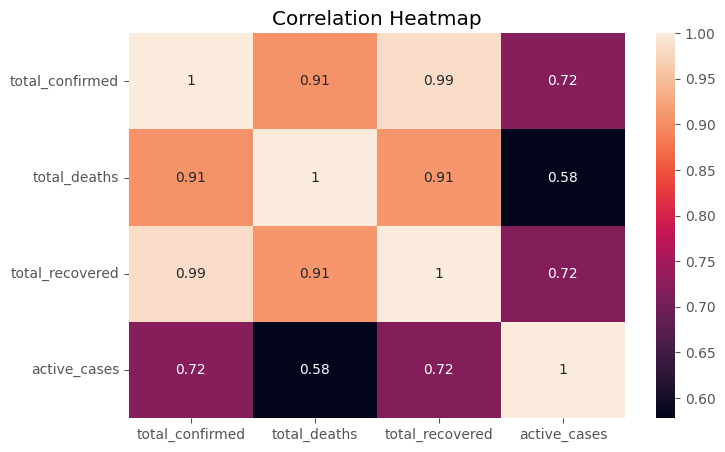

In [36]:
corr = summary_df[
    [
        'total_confirmed',
        'total_deaths',
        'total_recovered',
        'active_cases'
    ]
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

VISUALIZATION 9

**Country with Highest Death Rate**

This analysis identifies countries with the highest mortality percentage relative to confirmed cases

In [37]:
highest_death_rate = summary_df.sort_values(
    by='death_rate',
    ascending=False
).head(10)

highest_death_rate[
    ['country','death_rate']
]

,country,death_rate
223,Yemen,18.182587
222,Western Sahara,10.000000
194,Sudan,7.940670
158,Peru,5.963825
131,Mexico,5.647140
199,Syria,5.638189
187,Somalia,5.090882
62,Egypt,4.773245
0,Afghanistan,4.289691
24,Bosnia And Herzegovina,4.179481


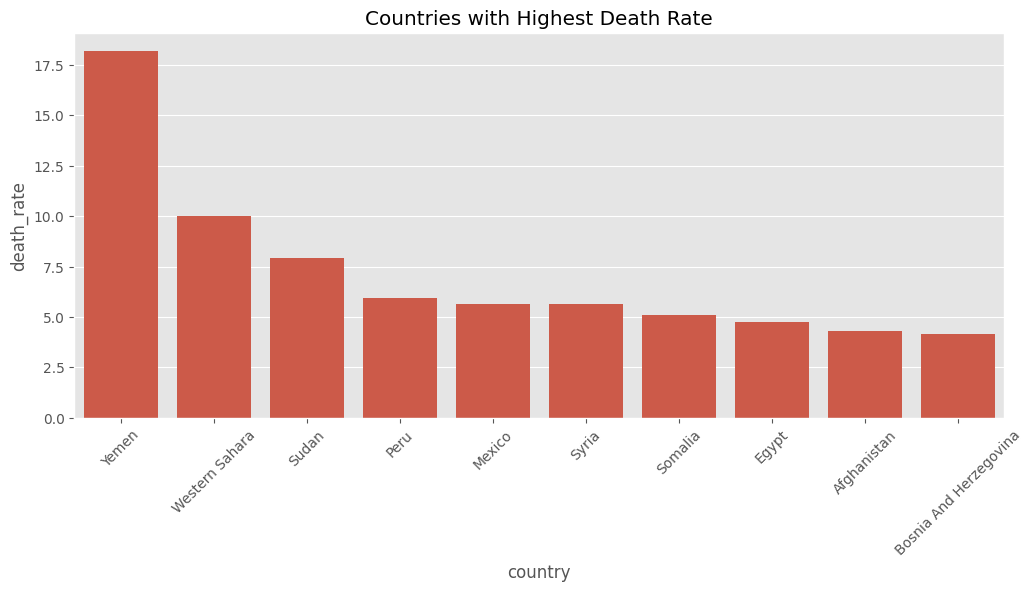

In [38]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='country',
    y='death_rate',
    data=highest_death_rate
)

plt.xticks(rotation=45)

plt.title('Countries with Highest Death Rate')

plt.show()

**Observation**

Countries with higher mortality rates may have faced challenges related to healthcare capacity, demographics, or pandemic management.

# Insights Report

## Insight 1
Countries with the highest confirmed COVID-19 cases also recorded the highest number of deaths.

## Insight 2
Global infections increased rapidly during peak outbreak periods.

## Insight 3
Recovery rates varied significantly across countries.

## Insight 4
The heatmap revealed a strong positive correlation between confirmed cases and deaths.

## Insight 5
A small number of countries contributed a large percentage of worldwide COVID-19 cases.

# Most Surprising Finding

The most surprising finding was the large variation in recovery rates across countries. Some countries managed to achieve high recovery percentages despite recording a large number of confirmed cases. This highlights the importance of healthcare systems, public health measures, and timely medical intervention during a pandemic. The analysis also showed how a few countries contributed disproportionately to global case counts.

# Conclusion

This project analyzed COVID-19 data using both daily and country-level datasets from Worldometer. Through data cleaning, exploratory analysis, feature engineering, and visualization, key trends related to infections, deaths, recoveries, and active cases were identified. The results demonstrate how data analytics can help understand global health crises and support data-driven decision-making.